# Divergence‑Type Diffusion in (1+1)D with the Kurganov–Tadmor scheme

Solves the flux‑conservative system

$\partial_t n + \partial_x q = 0,\qquad
\partial_t(\lambda q) + \partial_x\alpha + \frac{1}{\sigma T}q = 0$,

where $(n(\alpha)$ is the equilibrium charge density and $\lambda,\sigma T$ are constant constitutive parameters.

L = 50.0, Nx = 1000, dx = 0.1000, t_end = 10.0
Simulation finished after 201 snapshots.
Saved to ./KT_DivType/snapshots.npz


/tmp/ipykernel_1225/1831249546.py:221: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Greys_r", 256)


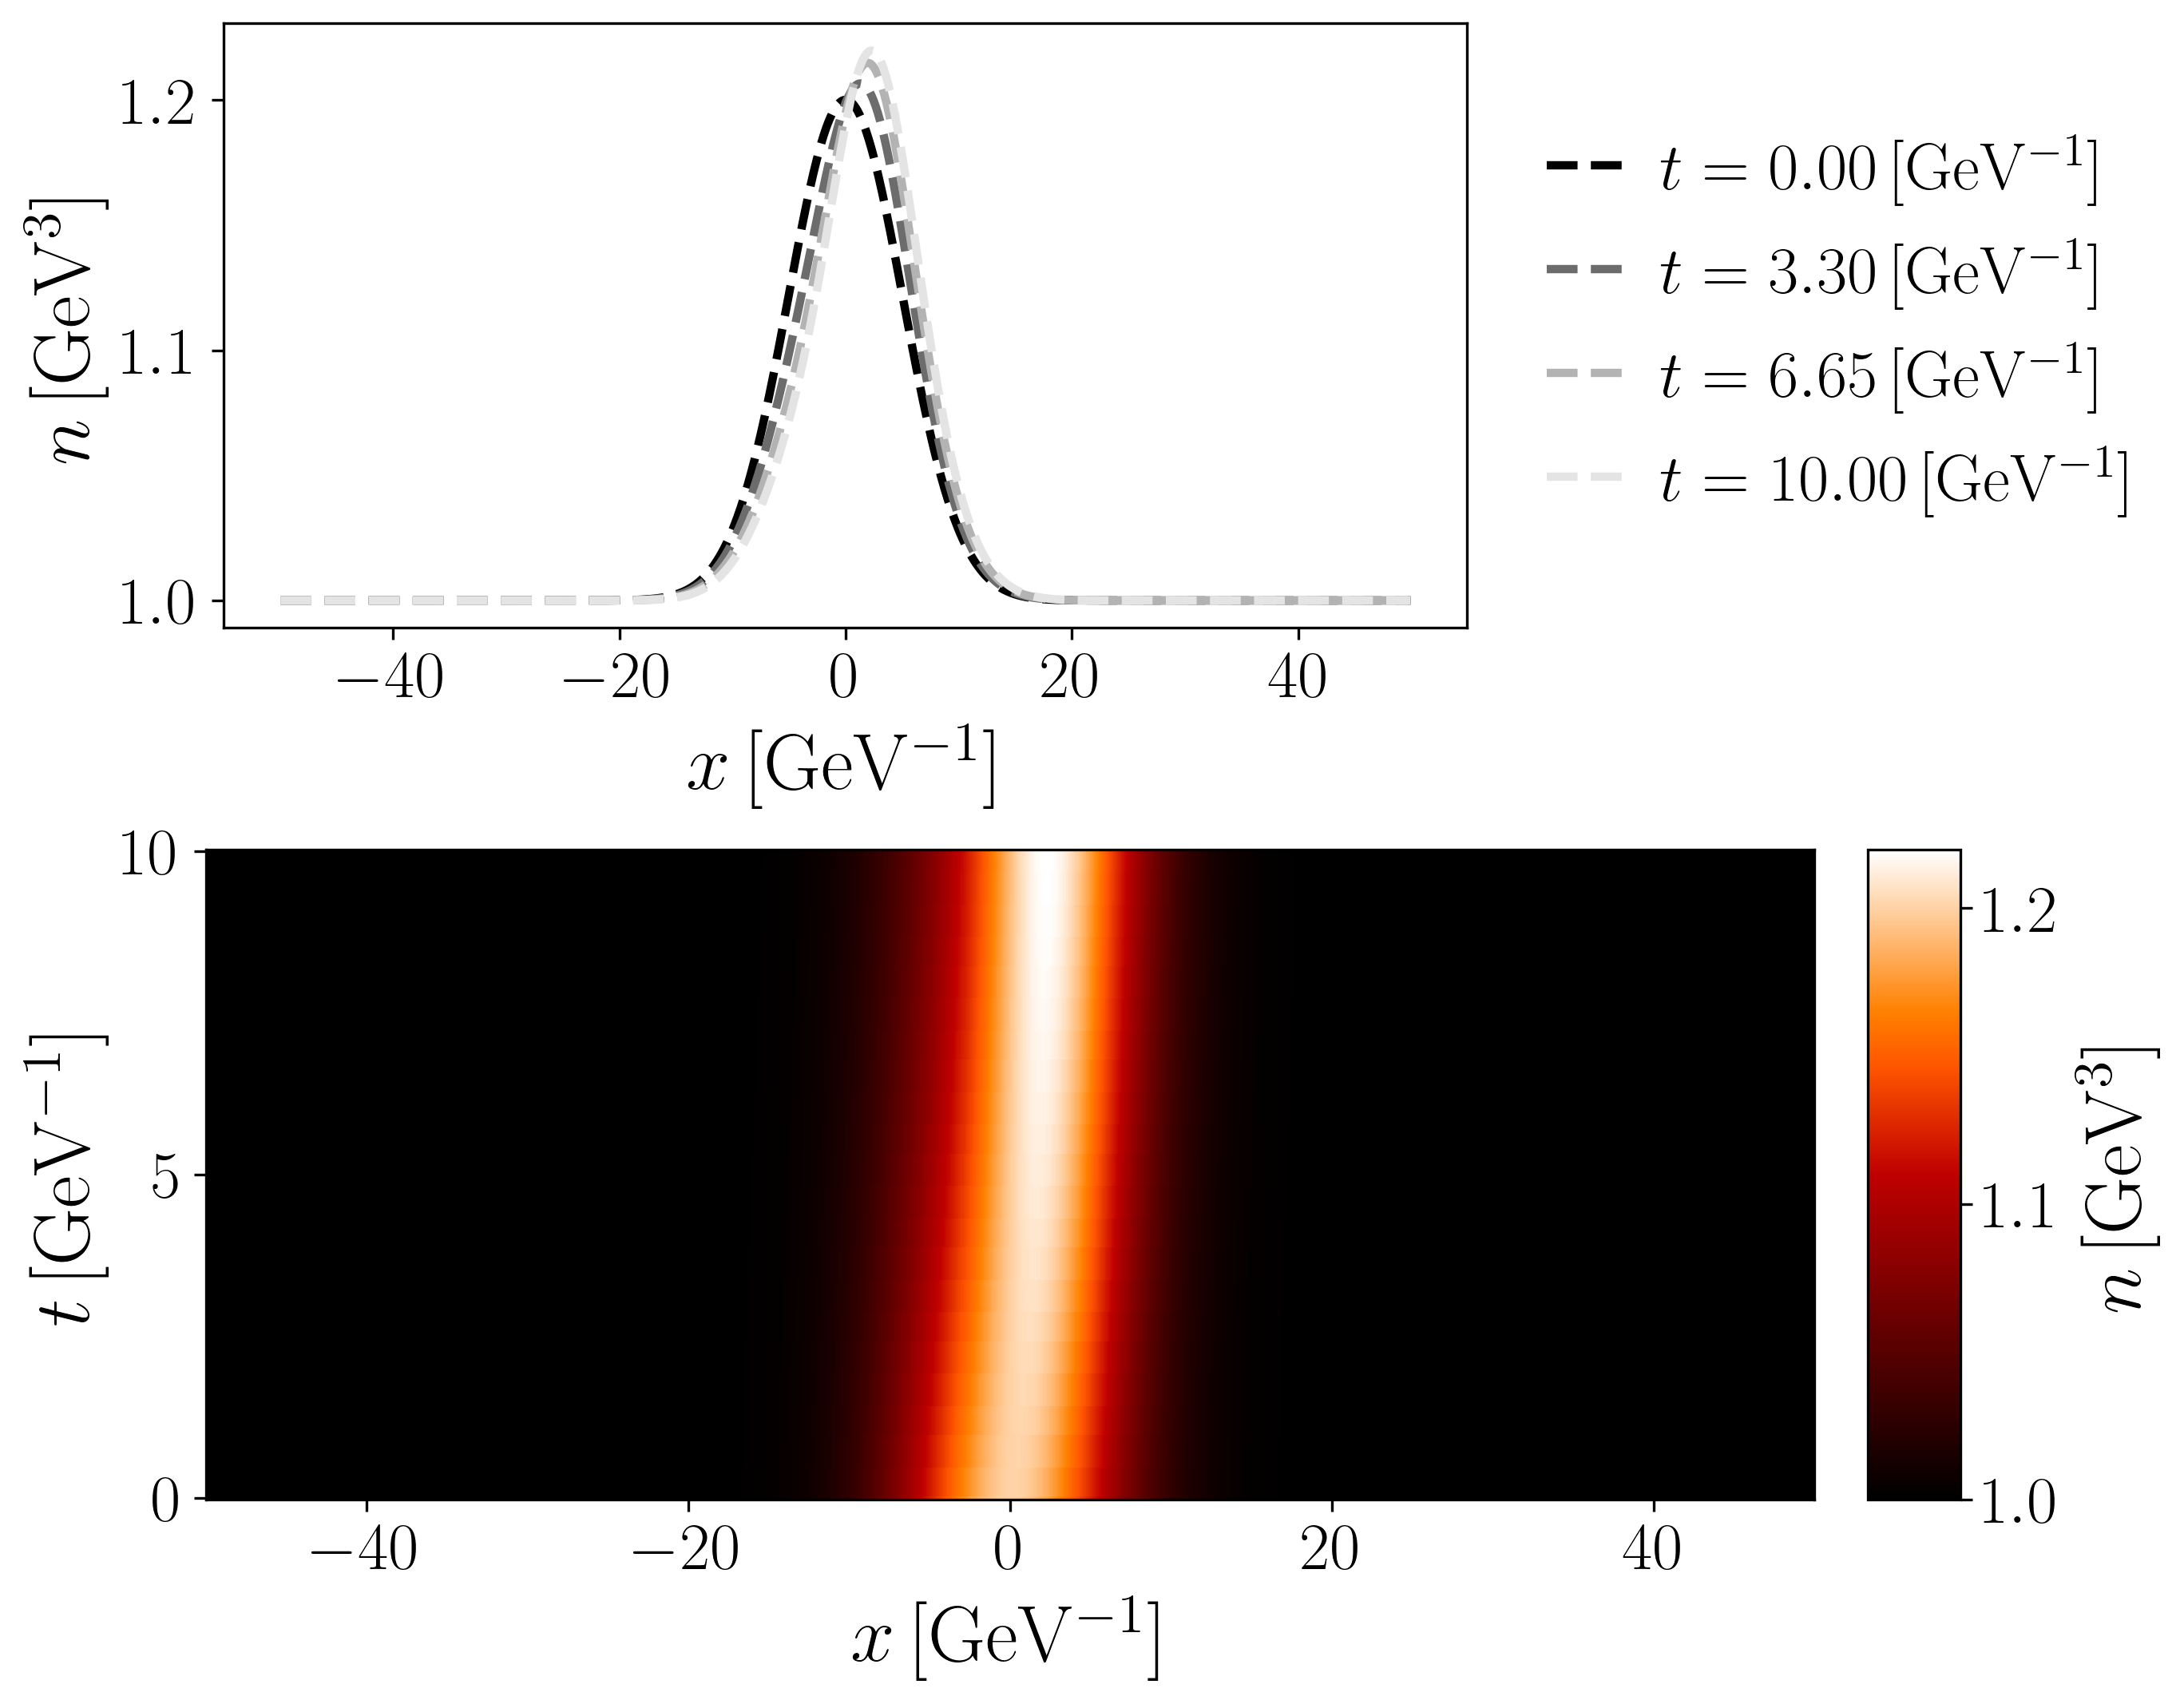

/tmp/ipykernel_1225/1831249546.py:221: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Greys_r", 256)


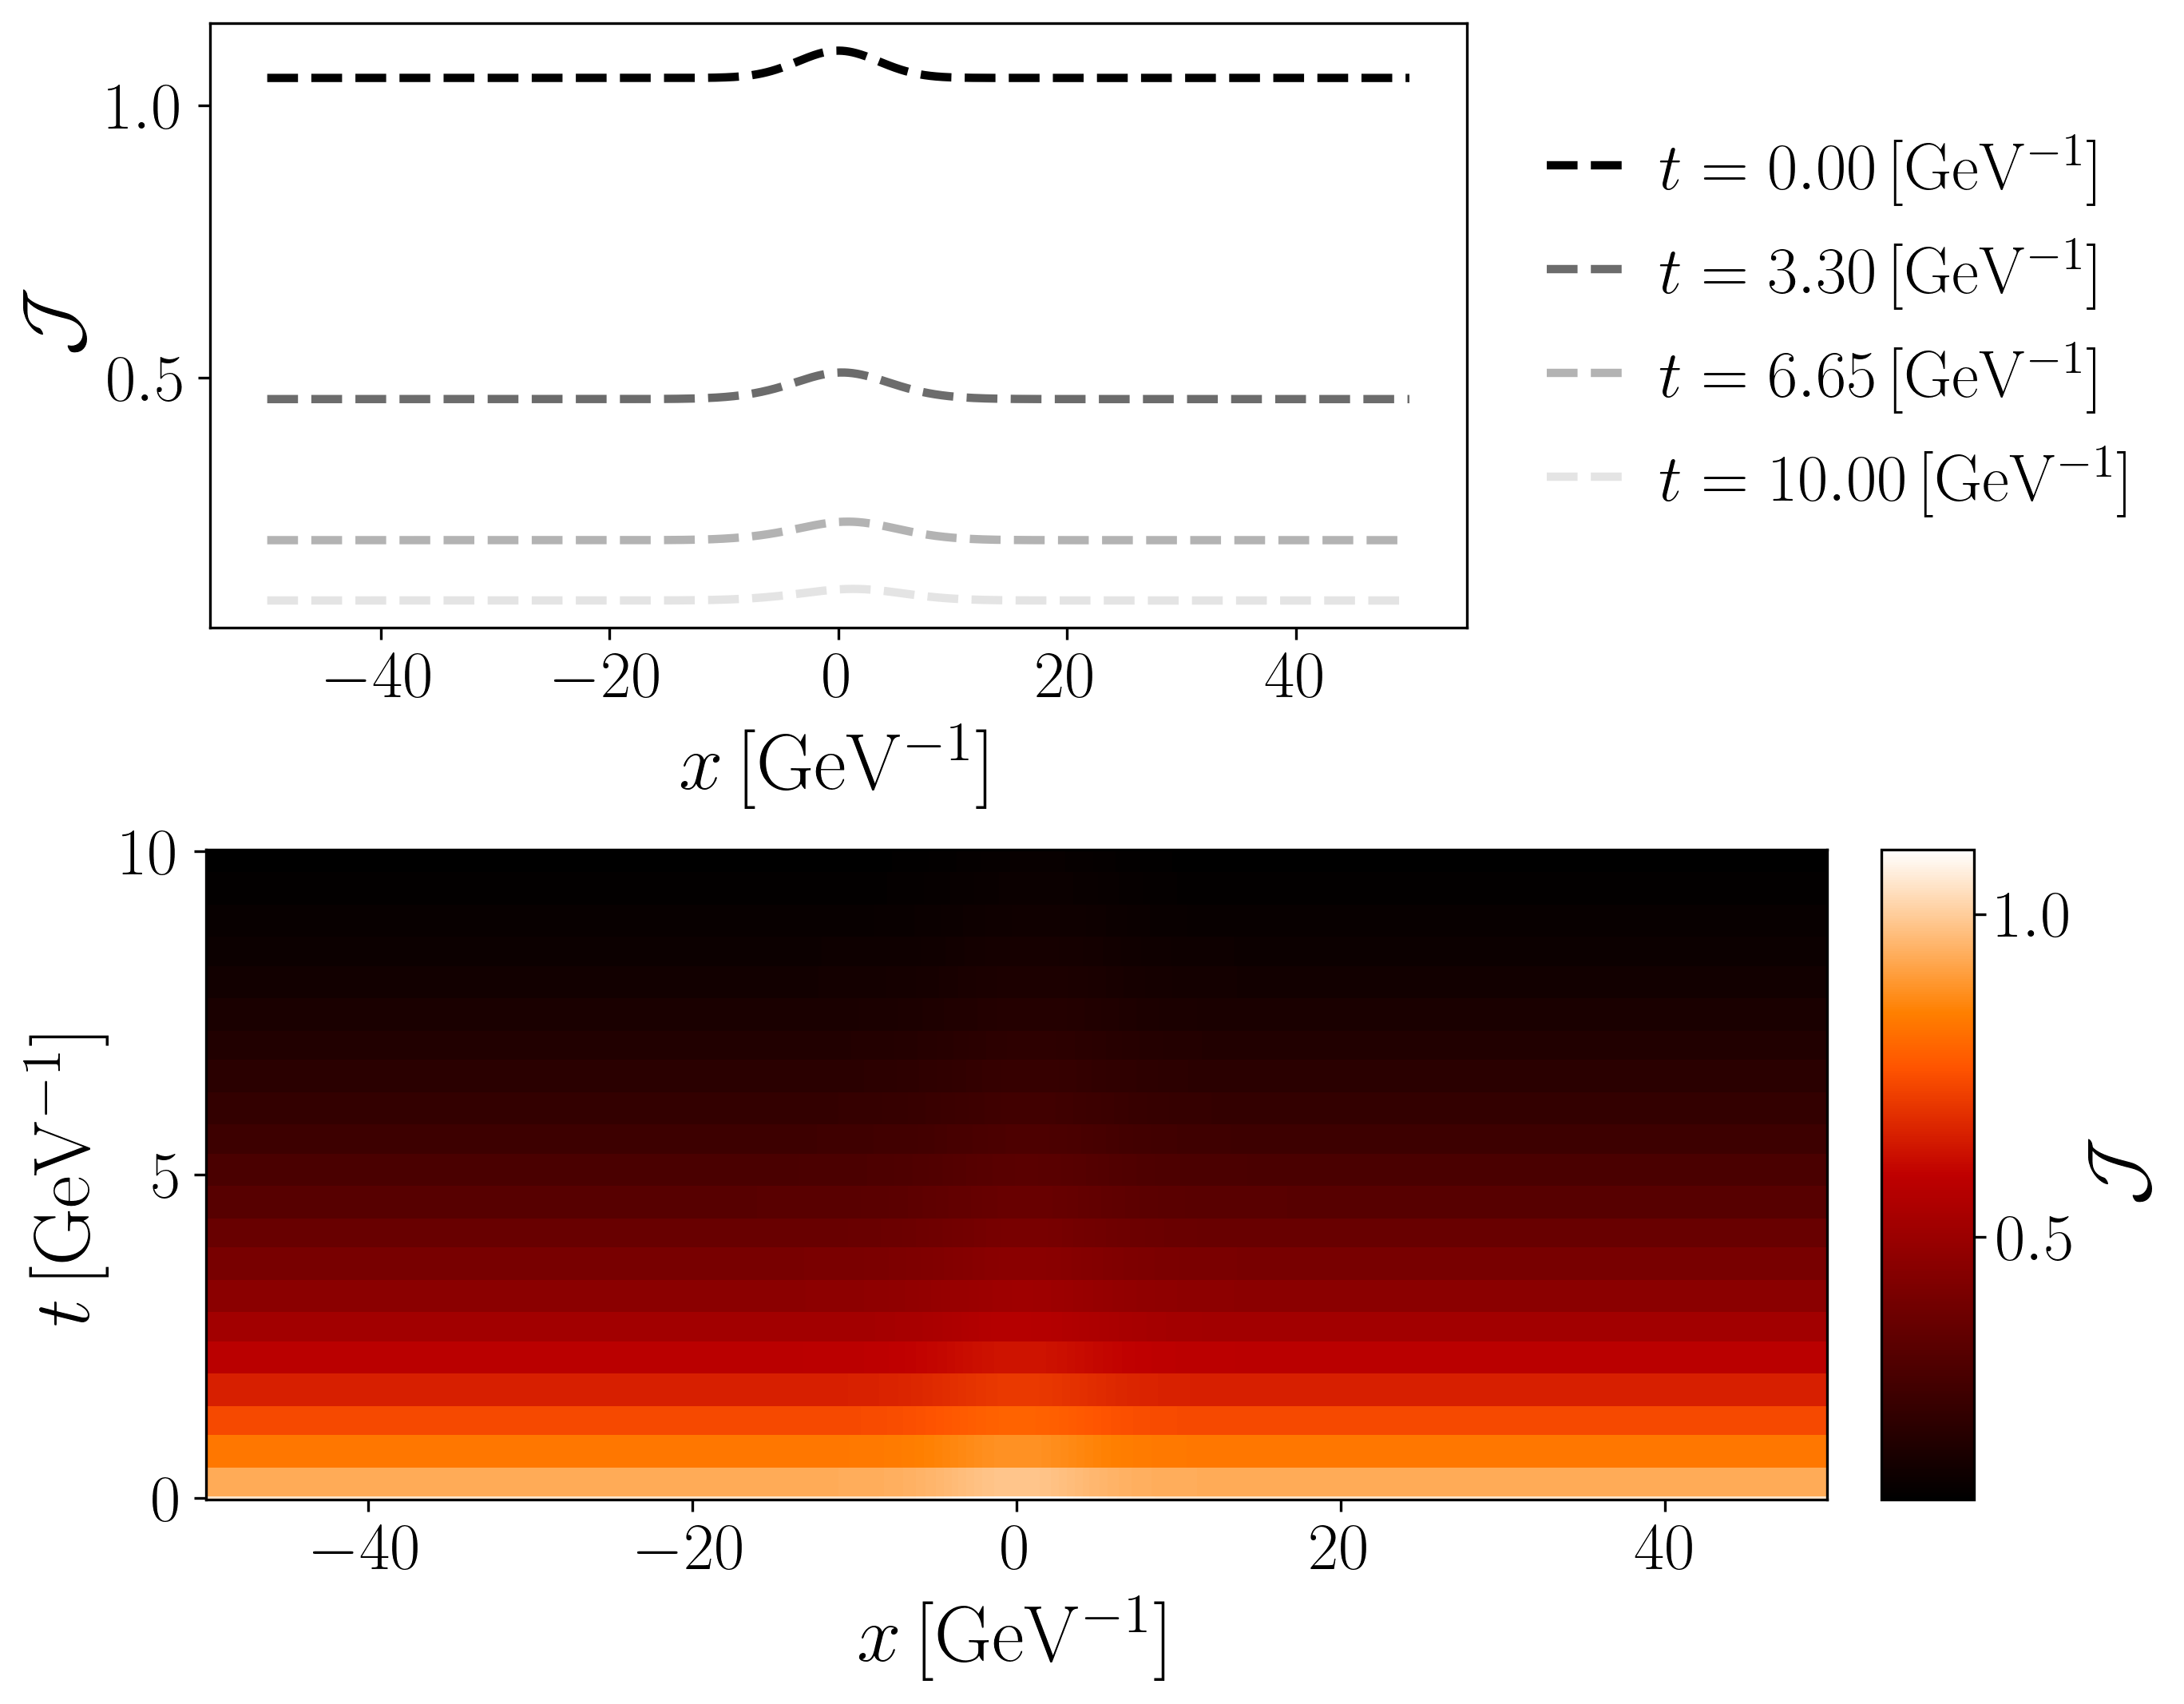

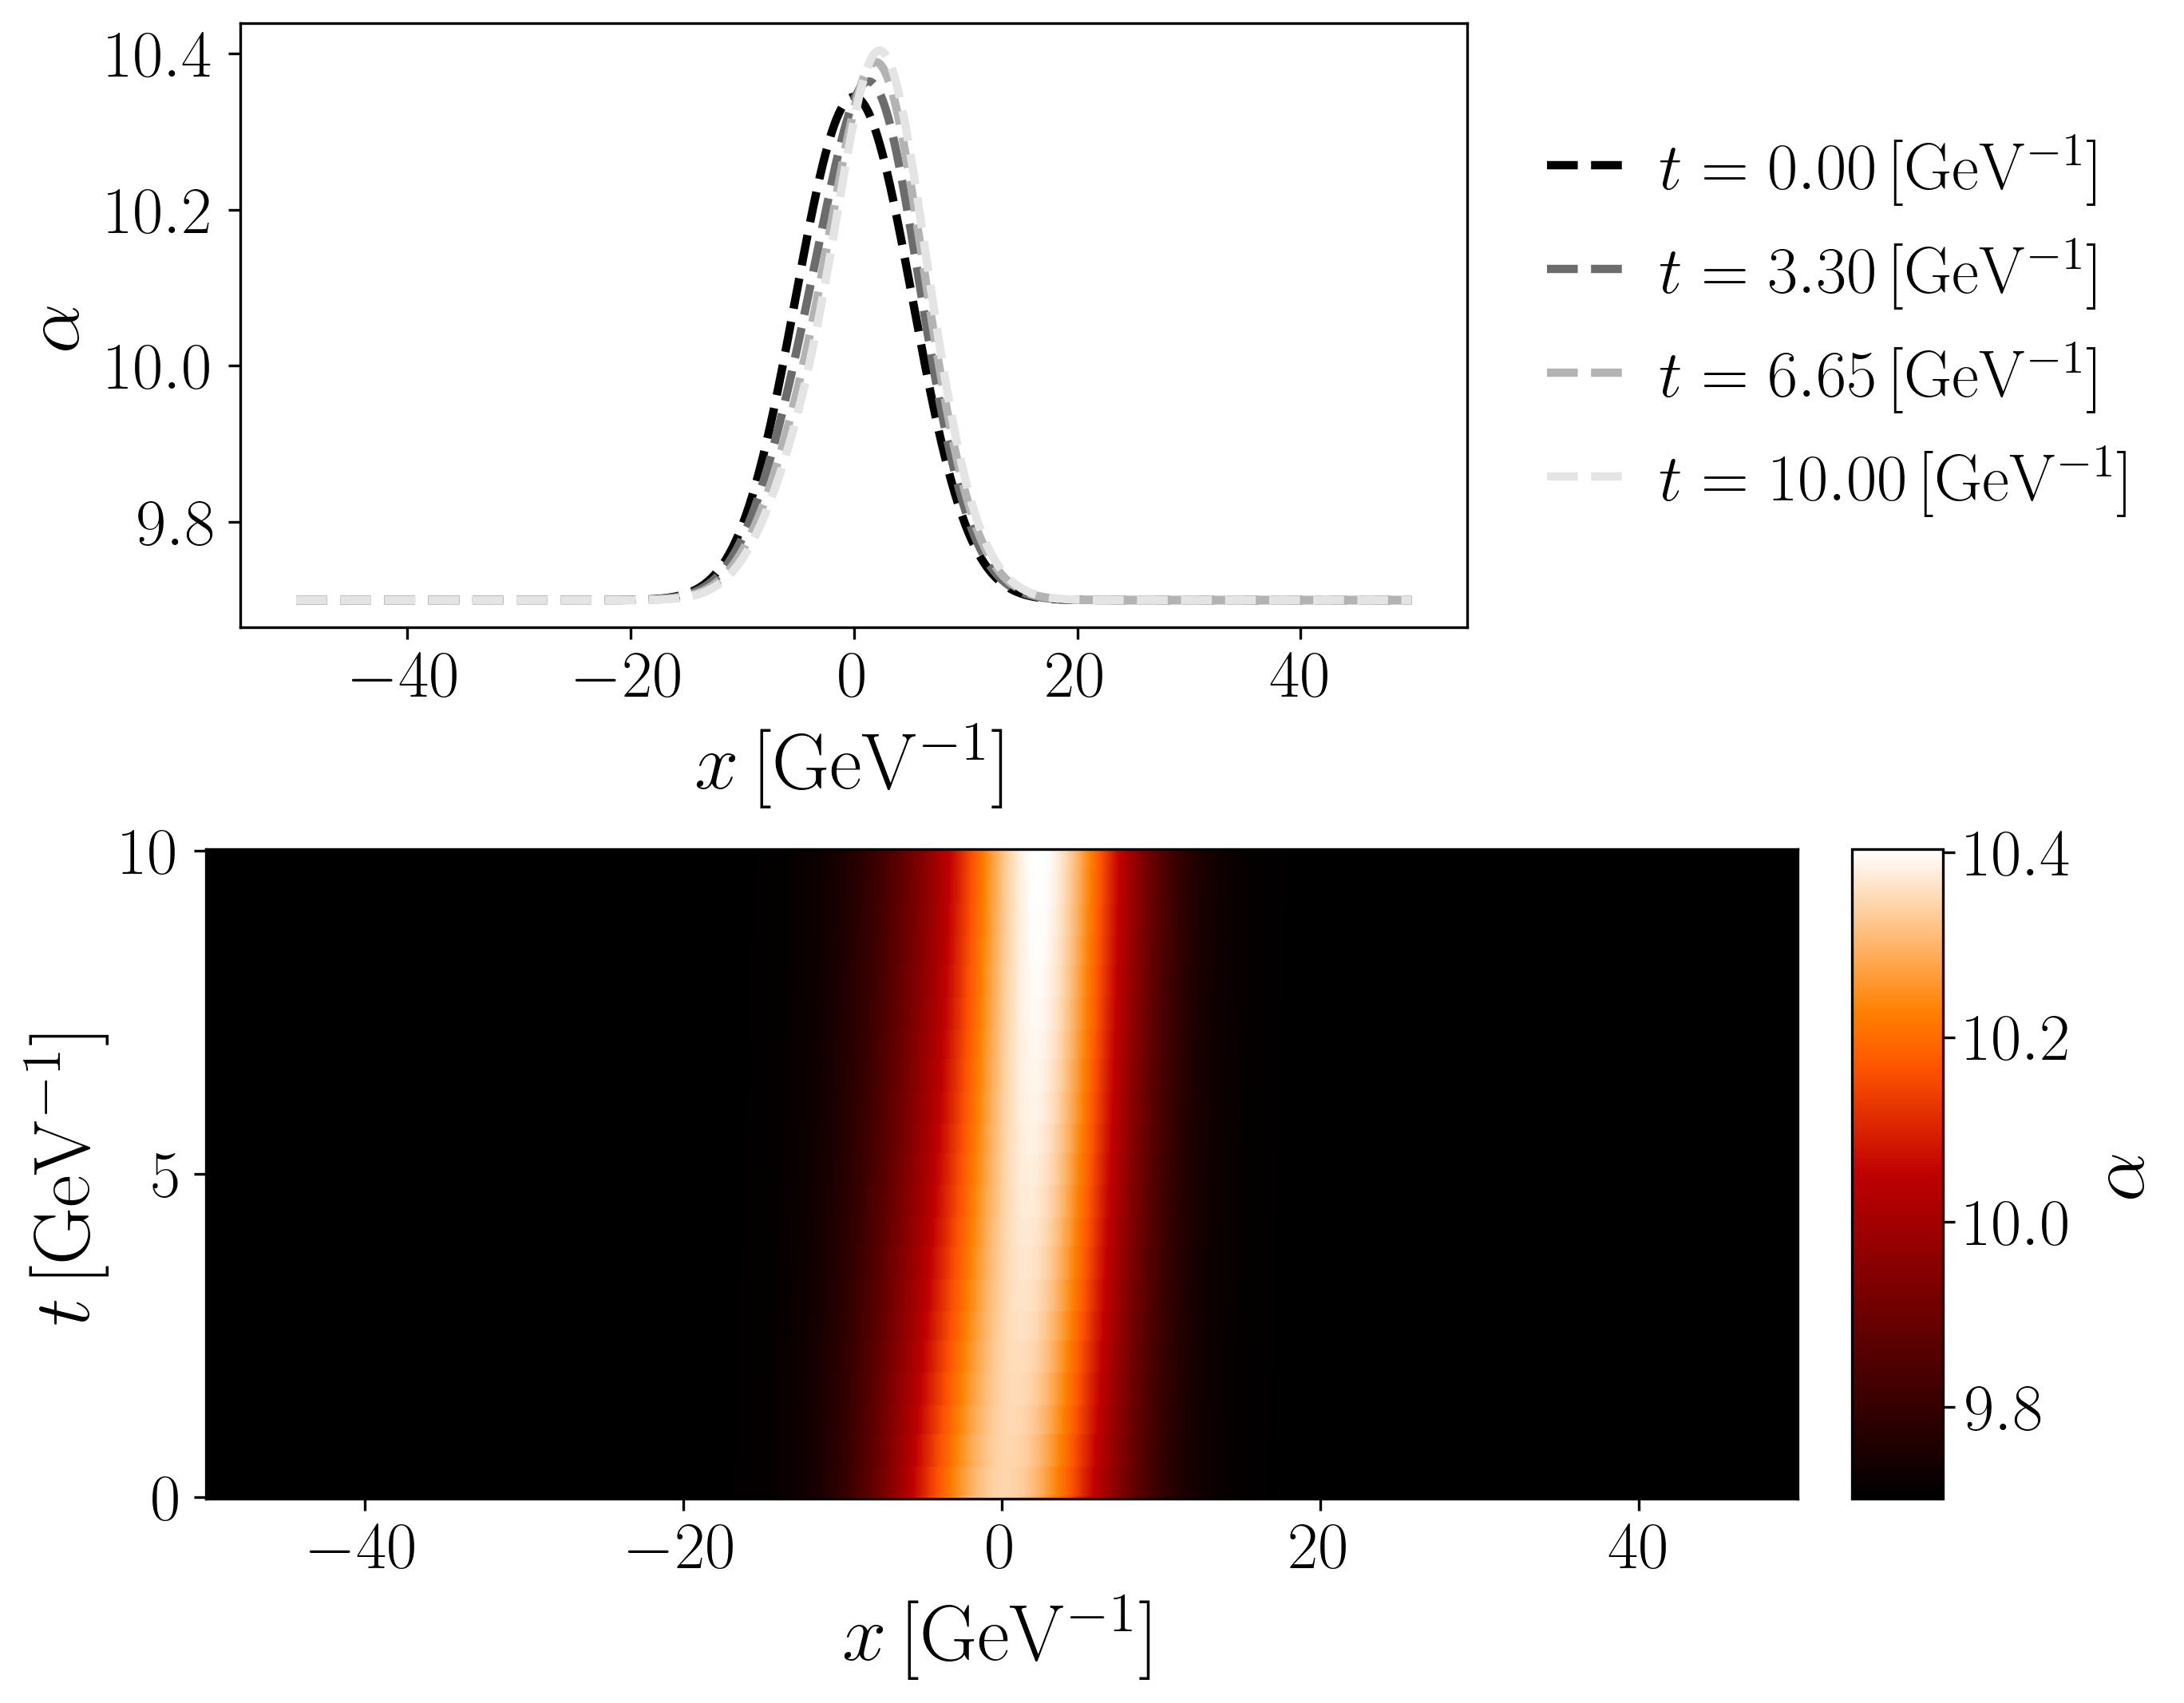

In [2]:
import numpy as np
from numba import jit
import matplotlib.pyplot as plt
import os

# ---------- physical parameters ----------
L         = 50.0
t_end     = 10.0
Nx        = 1000
dx        = 2.0 * L / Nx
xc        = np.linspace(-L + 0.5*dx, L - 0.5*dx, Nx)

T_const = 0.3
T_cube = T_const ** 3
lam = 500.0           # λ = τ_J/(σT) = constant

# ---------- constitutive functions (new EOS) ----------
@jit(nopython=True, cache=False)
def n_func(alpha):
    """Charge density n(α) = (T³/3)α + (T³/27)α³."""
    return (T_cube / 3.0) * alpha + (T_cube / 27.0) * alpha**3

@jit(nopython=True, cache=False)
def sigma_func(alpha):
    """Conductivity σ(α) = (15T/(4π))(1/27 + α²/(243π²))."""
    return (15.0 * T_const / (4.0 * np.pi)) * (1.0/27.0 + alpha**2 / (243.0 * np.pi**2))

@jit(nopython=True, cache=False)
def sigmaT_func(alpha):
    """σT used in the source term."""
    return sigma_func(alpha) * T_const

@jit(nopython=True, cache=False)
def lambda_func(alpha):
    """Λ(α) = τ_J/(σT) = 12 / n(α)"""
    return 12.0 / n_func(alpha)      

@jit(nopython=True, cache=False)
def alpha_from_n_func(n):
    """Analytical inverse: solve T³/3 α + T³/27 α³ = n."""
    a = T_cube / 3.0
    b = T_cube / 27.0
    p = a / b
    q = -n / b
    delta = (q / 2.0)**2 + (p / 3.0)**3
    sqrt_delta = np.sqrt(delta)
    t1 = -q/2.0 + sqrt_delta
    t2 = -q/2.0 - sqrt_delta
    u = np.sign(t1) * np.power(np.abs(t1), 1.0/3.0)
    v = np.sign(t2) * np.power(np.abs(t2), 1.0/3.0)
    return u + v

@jit(nopython=True, cache=False)
def T_func(t, x):
    return T_const * np.ones_like(x)

# ---------- initial conditions ----------
@jit(nopython=True, cache=False)
def make_IC(xc):
    p, qq, r = 0.2, 7.0, 1.0
    n_init = (p * np.exp(-(qq * xc / L)**2) + r) 

    d, f, g = 0.05, 10.0, 1.05
    q_init = (d * np.exp(-(f * xc / L)**2) + g) 
    return n_init, q_init

# ---------- helper: periodic shift ----------
@jit(nopython=True, cache=False)
def roll1d(arr, shift):
    n = arr.size
    s = shift % n
    out = np.empty_like(arr)
    if s == 0:
        out[:] = arr
    else:
        out[:s] = arr[-s:]
        out[s:] = arr[:-s]
    return out

# ---------- numerical flux (Kurganov–Tadmor) ----------
@jit(nopython=True, cache=False)
def numerical_flux(n, lam_q, T_arr):
    """
    n     : charge density at cell centres  (Nx,)
    lam_q : λ q at cell centres             (Nx,)   here λ=1 so lam_q = q
    T_arr : temperature at cell centres     (Nx,)
    Returns face fluxes H (2, Nx).
    """
    # minmod slopes
    dn  = (roll1d(n, -1) - n) / dx
    dnp = (n - roll1d(n, 1)) / dx
    sn = np.zeros_like(n)
    for i in range(Nx):
        if dn[i] * dnp[i] > 0.0:
            sn[i] = min(abs(dn[i]), abs(dnp[i])) * np.sign(dn[i])

    dlam = (roll1d(lam_q, -1) - lam_q) / dx
    dlamp = (lam_q - roll1d(lam_q, 1)) / dx
    slam = np.zeros_like(lam_q)
    for i in range(Nx):
        if dlam[i] * dlamp[i] > 0.0:
            slam[i] = min(abs(dlam[i]), abs(dlamp[i])) * np.sign(dlam[i])

    # face values
    n_minus   = n + 0.5 * dx * sn
    lam_minus = lam_q + 0.5 * dx * slam
    n_plus    = roll1d(n, -1) - 0.5 * dx * roll1d(sn, -1)
    lam_plus  = roll1d(lam_q, -1) - 0.5 * dx * roll1d(slam, -1)

    # physical fluxes: F = (q, α)
    q_minus = lam_minus / lam
    q_plus  = lam_plus  / lam
    alpha_minus = alpha_from_n_func(n_minus)
    alpha_plus  = alpha_from_n_func(n_plus)

    # wave speeds: dα/dn from the new EOS
    dalpha_dn_minus = 1.0 / (n_func(alpha_minus + 1e-8) - n_func(alpha_minus)) * 1e-8
    dalpha_dn_plus  = 1.0 / (n_func(alpha_plus + 1e-8) - n_func(alpha_plus)) * 1e-8
    dalpha_dn_minus = np.maximum(np.abs(dalpha_dn_minus), 1e-12)
    dalpha_dn_plus  = np.maximum(np.abs(dalpha_dn_plus),  1e-12)
    a_max = np.maximum(np.sqrt(dalpha_dn_minus / lam),
                       np.sqrt(dalpha_dn_plus  / lam))

    # KT flux
    H = np.zeros((2, Nx))
    H[0] = 0.5 * (q_minus + q_plus) - 0.5 * a_max * (n_plus - n_minus)
    H[1] = 0.5 * (alpha_minus + alpha_plus) - 0.5 * a_max * (lam_plus - lam_minus)
    return H

# ---------- time stepping (RK2) ----------
@jit(nopython=True, cache=False)
def rhs(n, lam_q, T_arr):
    """d/dt (n, lam_q) = -div(F) + source."""
    H = numerical_flux(n, lam_q, T_arr)   # shape (2, Nx)
    dU = np.zeros((2, Nx))
    dU[0] = -(H[0] - roll1d(H[0], 1)) / dx
    # source term:
    alpha = alpha_from_n_func(n)
    Lam = lam  # constant Lambda
    dU[1] = -(H[1] - roll1d(H[1], 1)) / dx - lam_q / (Lam * sigmaT_func(alpha))
    return dU

@jit(nopython=True, cache=False)
def step_RK2(n, lam_q, T_arr, dt):
    k1 = rhs(n, lam_q, T_arr)
    n1   = n     + dt * k1[0]
    q1   = lam_q + dt * k1[1]
    k2 = rhs(n1, q1, T_arr)
    n_out   = n     + 0.5 * dt * (k1[0] + k2[0])
    lam_out = lam_q + 0.5 * dt * (k1[1] + k2[1])
    return n_out, lam_out

# ---------- main simulation ----------
print(f"L = {L}, Nx = {Nx}, dx = {dx:.4f}, t_end = {t_end}")

n, q0 = make_IC(xc)
lam_q = lam * q0

save_times = np.linspace(0, t_end, 201)
save_idx   = 0
n_store    = np.zeros((len(save_times), Nx))
q_store    = np.zeros((len(save_times), Nx))
alpha_store= np.zeros((len(save_times), Nx))

n_store[0]   = n
q_store[0]   = q0
alpha_store[0] = alpha_from_n_func(n)

t = 0.0
while t < t_end:
    T_arr = T_func(t, xc)
    # characteristic speed
    alpha_cur = alpha_from_n_func(n)
    dalpha_dn = 1.0 / (n_func(alpha_cur + 1e-8) - n_func(alpha_cur)) * 1e-8
    dalpha_dn = np.maximum(np.abs(dalpha_dn), 1e-12)
    a_max = np.sqrt(dalpha_dn / lam)
    dt_cfl = np.min(0.4 * dx / a_max)
    dt = min(dt_cfl, t_end - t)

    n, lam_q = step_RK2(n, lam_q, T_arr, dt)
    t += dt

    while save_idx+1 < len(save_times) and t >= save_times[save_idx+1]:
        save_idx += 1
        n_store[save_idx]   = n
        q_store[save_idx]   = lam_q / lam
        alpha_store[save_idx] = alpha_from_n_func(n)

print(f"Simulation finished after {save_idx+1} snapshots.")

# ---------- save results ----------
run_dir = "./KT_DivType"
os.makedirs(run_dir, exist_ok=True)
np.savez(os.path.join(run_dir, "snapshots.npz"),
         t=save_times, x=xc,
         n=n_store, q=q_store, alpha=alpha_store)
print(f"Saved to {run_dir}/snapshots.npz")

# %% [KT plots in PINN style]
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

# -------- use the same style as the PINN plotting module --------
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 18,
    'axes.titlesize': 24,
    'axes.labelsize': 24,
    'legend.fontsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'font.serif': ['Computer Modern Roman'],
    'text.latex.preamble': r'\usepackage{amsmath}',
    'figure.dpi': 300,
    'savefig.dpi': 300
})

def custom_colormap():
    cmap = plt.get_cmap("Greys_r", 256)
    vals = np.interp(
        np.linspace(0, 1, 256),
        [0.0, 1/3, 2/3, 1.0],
        [0.0, 0.35, 0.59, 0.81]
    )
    cmap = cmap(vals)
    return ListedColormap(cmap)

def plot_kt_field(field, x_eval, t_eval, ylabel, cmap_heat='gist_heat'):
    """Replica of Plotting_DivType.plot_field_panel for KT data."""
    Nt = len(t_eval)
    times = np.linspace(0, Nt-1, 4, dtype=int)
    cmap = plt.get_cmap(custom_colormap())

    fig = plt.figure(figsize=(9, 7), constrained_layout=True)
    outer = gridspec.GridSpec(2, 1, figure=fig,
                              height_ratios=[0.48, 0.52], hspace=0.18)

    gs_top = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer[0],
        width_ratios=[1.15, 0.32], wspace=0.05)
    ax_snap = fig.add_subplot(gs_top[0, 0])
    ax_leg  = fig.add_subplot(gs_top[0, 1])

    gs_bot = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer[1],
        width_ratios=[1.05, 0.06], wspace=0.05)
    ax_heat = fig.add_subplot(gs_bot[0, 0])
    cax     = fig.add_subplot(gs_bot[0, 1])

    for i, ti in enumerate(times):
        ax_snap.plot(
            x_eval, field[ti],
            color=cmap(i/(len(times)-1)),
            ls='--', lw=2.5,
            label=fr'$t={t_eval[ti]:.2f}\,[\mathrm{{GeV^{{-1}}}}]$'
        )

    ax_snap.set_xlabel(r'$x\,{\rm [GeV^{-1}]}$')
    ax_snap.set_ylabel(ylabel)

    ax_leg.axis('off')
    h, l = ax_snap.get_legend_handles_labels()
    ax_leg.legend(h, l, loc='center', frameon=False,
                  handlelength=1.2, handletextpad=0.5)

    pcm = ax_heat.pcolormesh(x_eval, t_eval, field,
                             shading='auto', cmap=cmap_heat)
    ax_heat.set_xlabel(r'$x\,{\rm [GeV^{-1}]}$')
    ax_heat.set_ylabel(r'$t\,{\rm [GeV^{-1}]}$')

    cb = fig.colorbar(pcm, cax=cax)
    cb.set_label(ylabel)
    plt.show()

# -------- generate the three panels --------
# Make sure t_eval and x_eval are the same arrays used for PINN plots.
# Here we use save_times (1D) and xc (1D) from the KT simulation.
# The field arrays have shape (Nt, Nx) with Nt = len(save_times).
plot_kt_field(n_store, xc, save_times, ylabel=r'$n\,{\rm [GeV^3]}$')
plot_kt_field(q_store, xc, save_times, ylabel=r'$\mathcal{J}$')
plot_kt_field(alpha_store, xc, save_times, ylabel=r'$\alpha$')